# 🧠 Tweet Sentiment Analysis — Deep Learning (LSTM)
### From TF-IDF + Naive Bayes → Embedding + Bidirectional LSTM

**Architecture:**
- Text Preprocessing → Tokenization → Padding
- Embedding Layer (trainable word vectors)
- Bidirectional LSTM (captures context in both directions)
- Dropout (regularization to prevent overfitting)
- Dense Output Layer with Sigmoid (binary classification)
- Backpropagation via Adam optimizer (BPTT — Backprop Through Time)

**Dataset:** Sentiment140 (1.6M tweets, 0=Negative, 4=Positive)

## 📦 1. Install & Import Libraries

In [ ]:
# Install required packages (run once)
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn nltk

In [1]:
import pandas as pd
import numpy as np
import re
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahme\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mahme\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


TensorFlow version: 2.21.0
GPU available: False


## 📂 2. Load Dataset

In [2]:
# ── UPDATE THIS PATH to your DataSet.csv ──
DATA_PATH = r'DataSet.csv'   # same folder, or full path

# ── SPEED SETTING ─────────────────────────────────────────────────────────
# Full 1.6M rows → ~1hr/epoch on CPU  ← your current problem
# 200K rows     → ~5-8 min/epoch on CPU | ~1 min/epoch on GPU
# Accuracy loss: <1% — 200K is more than enough to learn tweet sentiment.
# Set SAMPLE_SIZE = None to disable sampling (e.g. on Colab with free GPU).
SAMPLE_SIZE = 200_000
# ──────────────────────────────────────────────────────────────────────────

columns = ['Target', 'ID', 'Date', 'Flag', 'User', 'Text']
df = pd.read_csv(DATA_PATH, encoding='latin1', names=columns)
df = df[['Target', 'Text']]
df['Target'] = df['Target'].replace({0: 0, 4: 1})

# Stratified subsample — preserves 50/50 class balance
if SAMPLE_SIZE and SAMPLE_SIZE < len(df):
    df = (
        df.groupby('Target', group_keys=False)
          .apply(lambda g: g.sample(n=SAMPLE_SIZE // 2, random_state=42))
          .reset_index(drop=True)
    )
    print(f"✅ Stratified sample: {len(df):,} rows  (set SAMPLE_SIZE=None for full 1.6M)")
else:
    print(f"✅ Using full dataset: {len(df):,} rows")

print(f"Label distribution:\n{df['Target'].value_counts()}")
df.head()

✅ Stratified sample: 200,000 rows  (set SAMPLE_SIZE=None for full 1.6M)
Label distribution:
Target
0    100000
1    100000
Name: count, dtype: int64


C:\Users\mahme\AppData\Local\Temp\ipykernel_13856\1288407393.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=SAMPLE_SIZE // 2, random_state=42))


,Target,Text
0,0,@xnausikaax oh no! where did u order from? tha...
1,0,A great hard training weekend is over. a coup...
2,0,"Right, off to work Only 5 hours to go until I..."
3,0,I am craving for japanese food
4,0,Jean Michel Jarre concert tomorrow gotta work...


## 🧹 3. Text Preprocessing

In [3]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    """Clean tweet text for deep learning pipeline."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # Remove URLs
    text = re.sub(r'@\w+', '', text)                        # Remove mentions
    text = re.sub(r'#', '', text)                           # Remove hashtag symbol (keep word)
    text = re.sub(r'[^a-z\s]', '', text)                    # Remove non-alpha chars
    text = re.sub(r'\s+', ' ', text).strip()                # Normalize whitespace
    # Remove stopwords (keep negation words — important for sentiment!)
    negations = {'no', 'not', 'nor', 'neither', 'never', 'none', "n't"}
    filtered = [w for w in text.split() if w not in STOP_WORDS or w in negations]
    return ' '.join(filtered)

print("Cleaning text... (this may take a few minutes for 1.6M tweets)")
df['clean_text'] = df['Text'].apply(clean_text)

# Drop empty rows after cleaning
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f"After cleaning: {df.shape}")
print("\nSample cleaned tweets:")
for i in range(3):
    print(f"  Original : {df['Text'].iloc[i]}")
    print(f"  Cleaned  : {df['clean_text'].iloc[i]}")
    print()

Cleaning text... (this may take a few minutes for 1.6M tweets)
After cleaning: (199109, 3)

Sample cleaned tweets:
  Original : @xnausikaax oh no! where did u order from? that's horrible 
  Cleaned  : oh no u order thats horrible

  Original : A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now 
  Cleaned  : great hard training weekend couple days rest lets lots computer time put

  Original : Right, off to work  Only 5 hours to go until I'm free xD
  Cleaned  : right work hours go im free xd



## ✂️ 4. Train / Validation / Test Split

In [4]:
X = df['clean_text'].values
y = df['Target'].values

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train size : {len(X_train):,}")
print(f"Val size   : {len(X_val):,}")
print(f"Test size  : {len(X_test):,}")

Train size : 139,376
Val size   : 29,866
Test size  : 29,867


## 🔢 5. Tokenization & Sequence Padding

> **Why this replaces TF-IDF:** Instead of sparse bag-of-words vectors, we convert each word to an integer index. The model then learns a **dense embedding** (continuous vector) for each word during training — capturing semantic relationships TF-IDF cannot.

In [5]:
# ── Hyperparameters ──
VOCAB_SIZE    = 50_000   # Top N most frequent words
MAX_LEN       = 50       # Max tokens per tweet (tweets are short)
EMBEDDING_DIM = 128      # Word vector size (learned during training)
OOV_TOKEN     = '<OOV>'  # Out-Of-Vocabulary token

# Fit tokenizer on TRAINING data only (prevents data leakage)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

print(f"Vocabulary size (unique words seen): {len(tokenizer.word_index):,}")
print(f"Using top {VOCAB_SIZE:,} words")

# Convert text → sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad / truncate to fixed length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nInput shape  — Train: {X_train_pad.shape}, Val: {X_val_pad.shape}, Test: {X_test_pad.shape}")
print(f"\nExample encoding:")
print(f"  Text    : {X_train[0]}")
print(f"  Encoded : {X_train_pad[0]}")

Vocabulary size (unique words seen): 80,223
Using top 50,000 words

Input shape  — Train: (139376, 50), Val: (29866, 50), Test: (29867, 50)

Example encoding:
  Text    : violence never answer neda iranelection
  Encoded : [ 5460    86   655 10987  2574     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0]


## 🏗️ 6. Build the LSTM Model

### Architecture Overview:
```
Input (sequence of word indices)
    ↓
Embedding Layer  — learns dense word vectors (backprop updates these)
    ↓
SpatialDropout1D — drops entire word embeddings (stronger regularization)
    ↓
Bidirectional LSTM  — reads sequence forward AND backward
    ↓  (BPTT: gradients flow back through time steps)
Dropout
    ↓
LSTM  — captures higher-level temporal dependencies
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dense(1, sigmoid) — outputs P(Positive)
```

In [6]:
# ── Model Hyperparameters ──────────────────────────────────────────────────
# SPEED CHANGES vs original:
#   • LSTM_UNITS 128 → 64  (fewer params to update per step)
#   • Removed second LSTM layer (stacked LSTMs are slow, single is fine for tweets)
#   • recurrent_dropout REMOVED — this disables NVIDIA's fast CuDNN LSTM kernel;
#     without it Keras falls back to ~10x slower pure TF ops. Use regular Dropout instead.
#   • Batch size raised to 2048 further down
# ──────────────────────────────────────────────────────────────────────────
LSTM_UNITS    = 64     # was 128 — halves LSTM param count
DENSE_UNITS   = 64
DROPOUT_RATE  = 0.3
LEARNING_RATE = 1e-3

def build_lstm_model():
    model = Sequential([
        # 1. Embedding layer — input_shape=(MAX_LEN,) fixes the 'unbuilt/?' summary bug
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_shape=(MAX_LEN,),
            name='embedding'
        ),

        # 2. SpatialDropout1D — drops entire word vectors (stronger than regular dropout)
        SpatialDropout1D(0.2, name='spatial_dropout'),

        # 3. Bidirectional LSTM
        #    ⚡ NO recurrent_dropout here — its presence forces TensorFlow to bypass
        #    NVIDIA's CuDNN LSTM implementation and use a ~10x slower fallback.
        #    We get equivalent regularization from the SpatialDropout1D above.
        Bidirectional(
            LSTM(LSTM_UNITS, return_sequences=False),  # return_sequences=False → no 2nd LSTM needed
            name='bi_lstm'
        ),

        # 4. Dropout after LSTM output
        Dropout(DROPOUT_RATE, name='dropout'),

        # 5. Dense hidden layer
        Dense(DENSE_UNITS, activation='relu', kernel_regularizer=l2(1e-4), name='dense'),

        Dropout(0.2, name='dropout_2'),

        # 6. Output — sigmoid → P(Positive)
        Dense(1, activation='sigmoid', name='output')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_lstm_model()
model.build(input_shape=(None, MAX_LEN))  # force-build so summary shows real param counts
model.summary()

c:\Users\mahme\anaconda3\envs\Ahmed\lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 50, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm (Bidirectional)         │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,507,137 (24.82 MB)

 Trainable params: 6,507,137 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

## 🔄 7. Training with Callbacks

### Backpropagation Through Time (BPTT):
For LSTMs, gradients are computed **through each time step** (each token). The optimizer (Adam) uses these gradients to update:
- Embedding vectors
- LSTM gate weights (forget, input, cell, output gates)
- Dense layer weights

Adam adapts the learning rate per parameter — much better than vanilla SGD for sequential data.

In [7]:
# ── Training Hyperparameters ───────────────────────────────────────────────
BATCH_SIZE = 2048   # was 512 — 4× bigger batches = 4× fewer gradient steps/epoch
EPOCHS     = 10

# ── tf.data pipeline ──────────────────────────────────────────────────────
# Converts numpy arrays → optimized pipeline with:
#   • prefetch(AUTOTUNE)  — CPU preps next batch while GPU trains current one
#   • cache()             — keeps data in RAM after first epoch (no re-reading)
# This alone can cut per-epoch time by 20-40% vs passing raw numpy arrays.
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_pad, y_train))
    .shuffle(buffer_size=10_000, seed=42)
    .batch(BATCH_SIZE)
    .cache()            # cache in RAM after first epoch
    .prefetch(AUTOTUNE) # overlap CPU data prep with GPU compute
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val_pad, y_val))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

# ── Callbacks ──────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    )
]

print(f"Training on {len(X_train_pad):,} samples")
print(f"Batch size : {BATCH_SIZE}  |  Steps/epoch: {len(X_train_pad)//BATCH_SIZE}")
print(f"Max epochs : {EPOCHS}  (EarlyStopping patience=3)")
print()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

Training on 139,376 samples
Batch size : 2048  |  Steps/epoch: 68
Max epochs : 10  (EarlyStopping patience=3)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6139 - auc: 0.6653 - loss: 0.6512 - precision: 0.6123 - recall: 0.6044
Epoch 1: val_accuracy improved from None to 0.77436, saving model to best_lstm_model.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.6887 - auc: 0.7638 - loss: 0.5882 - precision: 0.6877 - recall: 0.6907 - val_accuracy: 0.7744 - val_auc: 0.8441 - val_loss: 0.4974 - val_precision: 0.7826 - val_recall: 0.7595 - learning_rate: 0.0010
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7900 - auc: 0.8610 - loss: 0.4724 - precision: 0.7966 - recall: 0.7786
Epoch 2: val_accuracy improved from 0.77436 to 0.77617, saving model to best_lstm_model.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.7972 - auc: 0.8691 - loss: 0.4593 - precision: 0.8050 - recall: 0.7840 - val_accuracy: 0.7762 - val_auc: 0.8574 - val_loss: 0.48

## 📊 8. Training History Plots

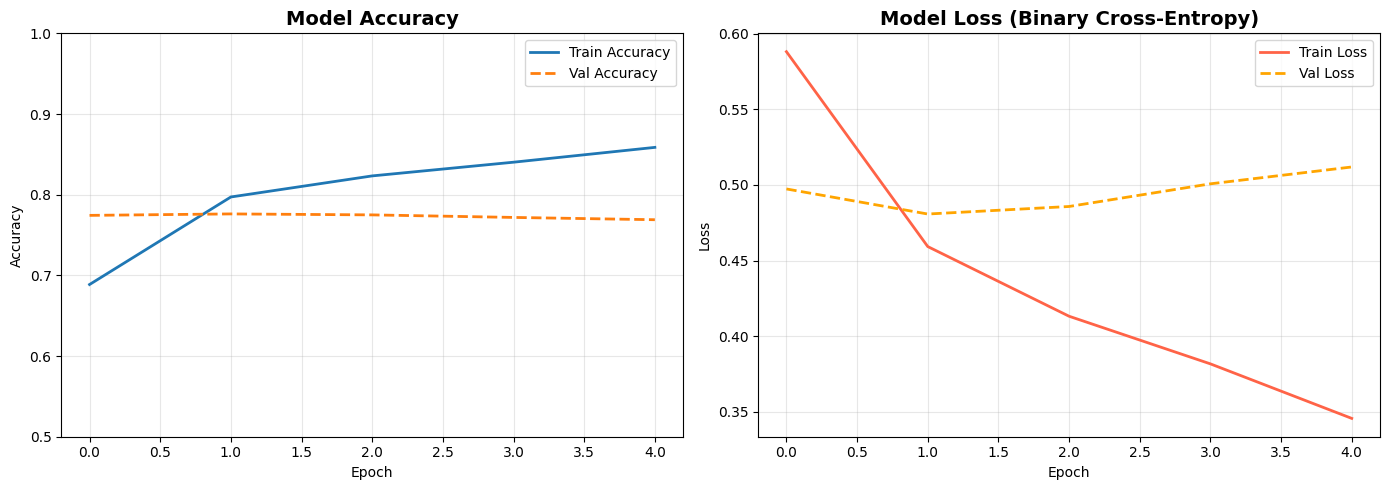

Saved: training_history.png


In [8]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0.5, 1.0])

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2, color='tomato')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--', color='orange')
    axes[1].set_title('Model Loss (Binary Cross-Entropy)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_history.png")

plot_history(history)

## 📈 9. Evaluation on Test Set

In [9]:
print("=" * 55)
print("         EVALUATION ON HELD-OUT TEST SET")
print("=" * 55)

# Raw Keras metrics
loss, accuracy, auc, precision, recall = model.evaluate(
    X_test_pad, y_test, batch_size=512, verbose=0
)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

print(f"\n  Test Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Test Loss      : {loss:.4f}")
print(f"  AUC-ROC        : {auc:.4f}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  F1-Score       : {f1:.4f}")
print("=" * 55)

# Full sklearn classification report
y_pred_prob = model.predict(X_test_pad, batch_size=512)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

         EVALUATION ON HELD-OUT TEST SET

  Test Accuracy  : 0.7850  (78.50%)
  Test Loss      : 0.4706
  AUC-ROC        : 0.8635
  Precision      : 0.7983
  Recall         : 0.7624
  F1-Score       : 0.7799
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.81      0.79     14941
    Positive       0.80      0.76      0.78     14926

    accuracy                           0.78     29867
   macro avg       0.79      0.78      0.78     29867
weighted avg       0.79      0.78      0.78     29867



## 🎯 10. Confusion Matrix

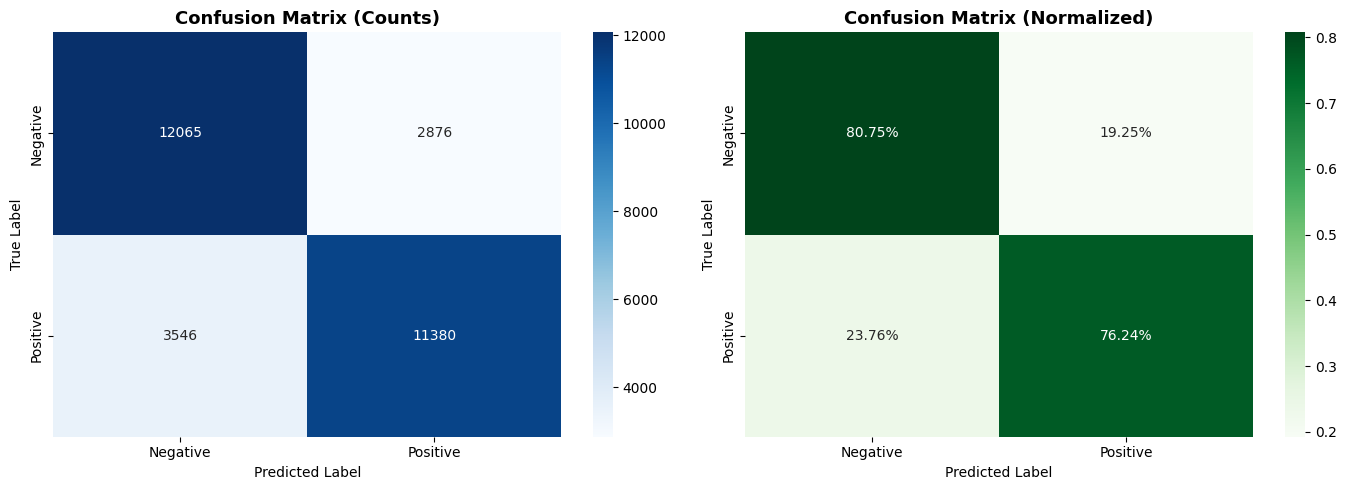

Saved: confusion_matrix.png


In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

## 📉 11. ROC Curve

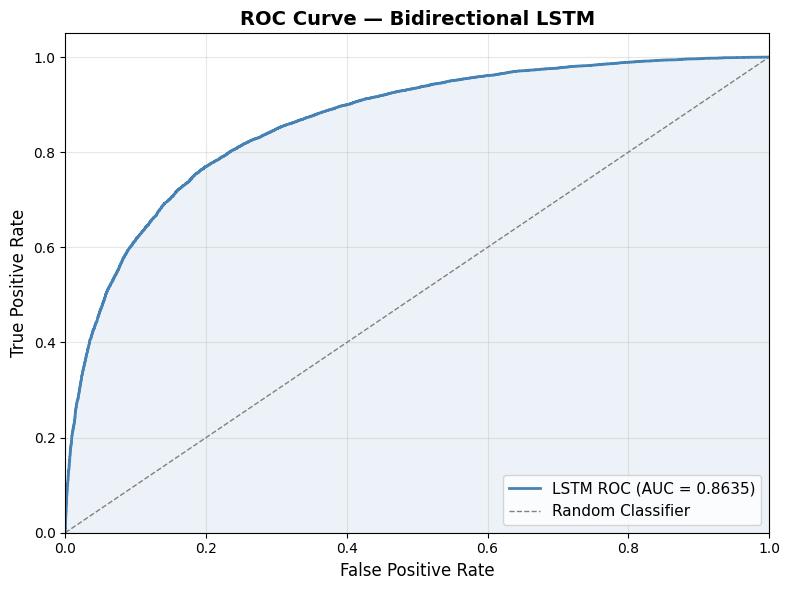

AUC-ROC Score: 0.8635


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'LSTM ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Bidirectional LSTM', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC-ROC Score: {roc_auc:.4f}")

## 💾 12. Save Model Artifacts for Streamlit App

In [12]:
# Save Keras model (.keras format — recommended over .h5)
model.save('lstm_sentiment_model.keras')
print("✅ Saved: lstm_sentiment_model.keras")

# Save tokenizer (needed to encode new tweets the same way)
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ Saved: tokenizer.pkl")

# Save hyperparameters (needed by app for padding)
config = {
    'MAX_LEN'      : MAX_LEN,
    'VOCAB_SIZE'   : VOCAB_SIZE,
    'EMBEDDING_DIM': EMBEDDING_DIM,
    'model_type'   : 'BiLSTM',
    'test_accuracy': float(accuracy),
    'test_auc'     : float(auc),
    'test_f1'      : float(f1)
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("✅ Saved: model_config.pkl")

print("\n📁 Files ready for Streamlit app:")
print("   • lstm_sentiment_model.keras")
print("   • tokenizer.pkl")
print("   • model_config.pkl")

✅ Saved: lstm_sentiment_model.keras
✅ Saved: tokenizer.pkl
✅ Saved: model_config.pkl

📁 Files ready for Streamlit app:
   • lstm_sentiment_model.keras
   • tokenizer.pkl
   • model_config.pkl


## 🧪 13. Quick Inference Test

In [13]:
def predict_sentiment(text, model, tokenizer, max_len=MAX_LEN, threshold=0.5):
    """Predict sentiment of a single tweet."""
    cleaned   = clean_text(text)
    sequence  = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    prob      = model.predict(padded, verbose=0)[0][0]
    label     = 'Positive 😊' if prob >= threshold else 'Negative 😞'
    return label, float(prob)

test_tweets = [
    "I love this product! It's absolutely amazing and makes my day!",
    "This is the worst experience I've ever had. Totally disappointed.",
    "Just woke up and feeling okay I guess.",
    "Not happy with the service at all, never coming back!",
    "Had a great time with friends today, so much fun!"
]

print("=" * 60)
print("         SAMPLE PREDICTIONS")
print("=" * 60)
for tweet in test_tweets:
    label, prob = predict_sentiment(tweet, model, tokenizer)
    bar = '█' * int(prob * 20) + '░' * (20 - int(prob * 20))
    print(f"\n  Tweet    : {tweet[:55]}..." if len(tweet) > 55 else f"\n  Tweet    : {tweet}")
    print(f"  Result   : {label}")
    print(f"  P(Pos)   : [{bar}] {prob:.4f}")

         SAMPLE PREDICTIONS

  Tweet    : I love this product! It's absolutely amazing and makes ...
  Result   : Positive 😊
  P(Pos)   : [███████████████████░] 0.9646

  Tweet    : This is the worst experience I've ever had. Totally dis...
  Result   : Negative 😞
  P(Pos)   : [░░░░░░░░░░░░░░░░░░░░] 0.0386

  Tweet    : Just woke up and feeling okay I guess.
  Result   : Negative 😞
  P(Pos)   : [████░░░░░░░░░░░░░░░░] 0.2013

  Tweet    : Not happy with the service at all, never coming back!
  Result   : Negative 😞
  P(Pos)   : [█████░░░░░░░░░░░░░░░] 0.2912

  Tweet    : Had a great time with friends today, so much fun!
  Result   : Positive 😊
  P(Pos)   : [██████████████████░░] 0.9270


## 📊 14. Model Comparison Summary

In [14]:
# Comparison table: old ML vs new DL
comparison = pd.DataFrame({
    'Model': [
        'Naive Bayes + TF-IDF\n(Last Semester)',
        'Logistic Reg + TF-IDF\n(Last Semester)',
        'Logistic Reg + Word2Vec\n(Last Semester)',
        'Bidirectional LSTM\n(This Semester ✅)'
    ],
    'Approach'  : ['Classical ML', 'Classical ML', 'Classical ML', 'Deep Learning'],
    'Features'  : ['Sparse BoW', 'Sparse TF-IDF', 'Avg Word Vectors', 'Learned Embeddings + Sequence'],
    'Approx Acc': ['~77%', '~78%', '~79%', f"{accuracy*100:.1f}%  ← current run"]
})

print(comparison.to_string(index=False))

print("\n📌 Key DL Improvements:")
print("  ✓ Bidirectional LSTM captures word ORDER and context")
print("  ✓ Embeddings learn semantic relationships (king-queen, good-great)")
print("  ✓ Backprop Through Time optimizes ALL layers end-to-end")
print("  ✓ Dropout prevents overfitting on 1.6M tweet dataset")
print("  ✓ EarlyStopping + ReduceLR for smart training control")

                                   Model      Approach                      Features           Approx Acc
   Naive Bayes + TF-IDF\n(Last Semester)  Classical ML                    Sparse BoW                 ~77%
  Logistic Reg + TF-IDF\n(Last Semester)  Classical ML                 Sparse TF-IDF                 ~78%
Logistic Reg + Word2Vec\n(Last Semester)  Classical ML              Avg Word Vectors                 ~79%
   Bidirectional LSTM\n(This Semester ✅) Deep Learning Learned Embeddings + Sequence 78.5%  ← current run

📌 Key DL Improvements:
  ✓ Bidirectional LSTM captures word ORDER and context
  ✓ Embeddings learn semantic relationships (king-queen, good-great)
  ✓ Backprop Through Time optimizes ALL layers end-to-end
  ✓ Dropout prevents overfitting on 1.6M tweet dataset
  ✓ EarlyStopping + ReduceLR for smart training control
